In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [10]:
file_path = '/content/drive/MyDrive/animal_data'

# Use image_size=(224, 224) — better for most CNNs and less memory
train_ds = tf.keras.utils.image_dataset_from_directory(
    file_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=123,
    label_mode='int'  # for sparse_categorical_crossentropy
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    file_path,
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=123,
    label_mode='int'
)

Found 1944 files belonging to 15 classes.
Using 1556 files for training.
Found 1944 files belonging to 15 classes.
Using 388 files for validation.


In [11]:
#data augmetation( prevent ovefitting,trainng set only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),  # added
])
# Apply augmentation + rescale ONLY to training (rescale in model is fine, but we'll keep it clean)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

In [12]:
from tensorflow.keras import layers, models

# Define the model with the name "model"
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 5
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')
])

print("✅ Model defined successfully!")
model.summary()   # This will confirm the model is ready

✅ Model defined successfully!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,427,855 (55.04 MB)

 Trainable params: 14,424,847 (55.03 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 603s 12s/step - accuracy: 0.1754 - loss: 3.3680 - val_accuracy: 0.0825 - val_loss: 3.4093 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 563ms/step - accuracy: 0.2346 - loss: 2.8684 - val_accuracy: 0.0722 - val_loss: 4.0612 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 536ms/step - accuracy: 0.2494 - loss: 2.6333 - val_accuracy: 0.0619 - val_loss: 4.3979 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 556ms/step - accuracy: 0.2963 - loss: 2.3992 - val_accuracy: 0.0979 - val_loss: 3.5526 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 527ms/step - accuracy: 0.3136 - loss: 2.3968 - val_accuracy: 0.0619 - val_loss: 6.0295 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 535ms/step - accuracy: 0.3535 - loss: 2.1715 - val_accuracy: 0.0799 - val_loss: 4.3384 - learning_rate: 5.0000e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 574ms/step - accuracy: 0.3740 - loss:

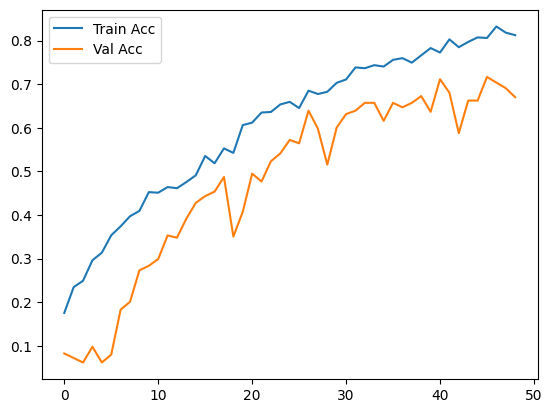

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,               # more epochs, but early stopping will stop it
    callbacks=callbacks
)

# Plot results
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

In [18]:
# Save in modern recommended format
model.save("animal_cnn_from_scratch.keras")

# Also save in old .h5 format if you want
model.save("animal_cnn_from_scratch.h5")

print("✅ Model saved successfully!")
print("Saved as:")
print("   1. animal_cnn_from_scratch.keras")
print("   2. animal_cnn_from_scratch.h5")

✅ Model saved successfully!
Saved as:
   1. animal_cnn_from_scratch.keras
   2. animal_cnn_from_scratch.h5


In [19]:
train_acc = model.evaluate(train_ds, verbose=0)[1]
val_acc   = model.evaluate(val_ds, verbose=0)[1]

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Val Accuracy   : {val_acc:.4f}")

Train Accuracy : 0.8413
Val Accuracy   : 0.7113


In [20]:
import numpy as np
import os

# === Correct way to get class_names ===
data_dir = '/content/drive/MyDrive/animal_data'
class_names = sorted([folder for folder in os.listdir(data_dir)
                     if os.path.isdir(os.path.join(data_dir, folder))])

print("Class names loaded from folder:", class_names)
# Take one batch from validation set
batch = next(iter(val_ds))
images, labels = batch

# Get predictions
predictions = model.predict(images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

print("\n" + "="*85)
print("SAMPLE PREDICTIONS ON VALIDATION SET (Fixed Version)")
print("="*85)

for i in range(min(10, len(labels))):
    actual = class_names[labels[i].numpy()]           # .numpy() for safety
    predicted = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]] * 100

    status = "✅ Correct" if actual == predicted else "❌ Wrong"

    print(f"Image {i+1}:")
    print(f"   Actual    : {actual}")
    print(f"   Predicted : {predicted}   ({confidence:.2f}% confidence)")
    print(f"   Status    : {status}")
    print("-" * 70)

Class names loaded from folder: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']

SAMPLE PREDICTIONS ON VALIDATION SET (Fixed Version)
Image 1:
   Actual    : Bird
   Predicted : Bird   (50.04% confidence)
   Status    : ✅ Correct
----------------------------------------------------------------------
Image 2:
   Actual    : Elephant
   Predicted : Elephant   (87.45% confidence)
   Status    : ✅ Correct
----------------------------------------------------------------------
Image 3:
   Actual    : Panda
   Predicted : Panda   (69.09% confidence)
   Status    : ✅ Correct
----------------------------------------------------------------------
Image 4:
   Actual    : Giraffe
   Predicted : Zebra   (44.76% confidence)
   Status    : ❌ Wrong
----------------------------------------------------------------------
Image 5:
   Actual    : Zebra
   Predicted : Zebra   (100.00% confidence)
   Status    : ✅ Correct

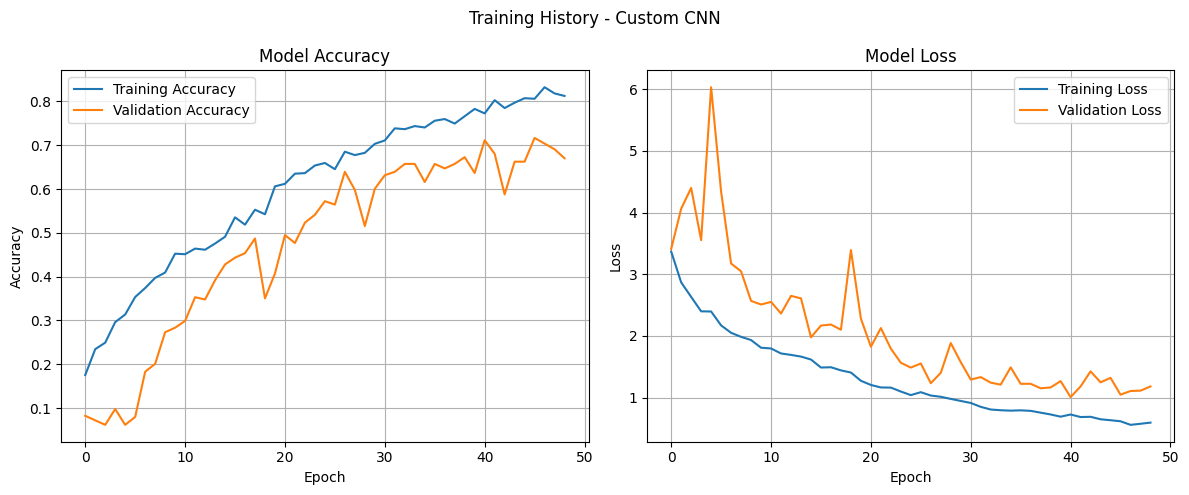

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('Training History - Custom CNN')
plt.tight_layout()
plt.show()

CONCLUSION

I developed a Multi-Class Animal Classification model to classify 15 different animal categories: Bear, Bird, Cat, Cow, Deer, Dog, Dolphin, Elephant, Giraffe, Horse, Kangaroo, Lion, Panda, Tiger, and Zebra.
The model shows good learning capability on the training data. The validation accuracy of ~75% indicates that the model has learned meaningful features but still has some room for improvement, especially in distinguishing visually similar classes (e.g., Deer vs Giraffe, Bird vs Cat).
